[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/04_evaluation.ipynb)

# 04 — Evaluation and Method Comparison

**Inputs.** The newest finished run of each method and seed under `outputs/optim/`, the baseline radio map, and the
processed tables. **Outputs.** `reports/tables/04_evaluation/` and `reports/figures/04_evaluation/`.

No GPU is needed and nothing is re-traced. Every table and figure is built by `src/evaluation/run.py`, the same code
`task evaluate` runs; this notebook only presents them.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation.run import evaluate

# evaluate() seeds, sets the figure defaults and saves every table and figure itself.
cfg = load_config(overrides=CONFIG_OVERRIDES)
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

Build every table and figure once. Run directories that did not finish writing are skipped with a `WARNING` line.

In [3]:
results = evaluate(cfg, in_colab=IN_COLAB)

## 1. Evaluation Objective

This notebook compares search methods for **multi-band antenna tilt coordination**: one absolute tilt per cell-band
pair, chosen to

* reduce coverage holes,
* reduce co-band coverage overlap and the number of overlapping neighbours,
* reduce weak coverage,
* raise the signal and interference levels where coverage exists,
* serve more UEs within the cells' PRB capacity,
* keep the load off any one cell and spread evenly across them,

at a reasonable number of expensive ray-tracing evaluations. The ten KPIs are reported side by side and
weighed equally; none is ranked above another, and each is reported over all bands and per band. The single
number a search maximises is the objective $J$ of [ADR 0010](../docs/adr/0010-monotone-strength-aware-objective.md),
which is reported beside the KPIs, not in place of them.

$J$ and the KPIs are both **tile-uniform**. ADR 0010 deleted the demand weighting ADR 0007 introduced, having
measured it as worth 0.0005 of $J$: the MDT reports on 3.0 % of the grid, and with the weight floored at 1 the
mean weight was 1.0035. Where the traffic stands is still reported, in section 10.2, and optimised by nothing.

Peak PRB utilisation is no longer among the KPIs either. It spanned 0.798284 to 0.799999 across the 318
candidates of the previous study - the 0.8 admission ceiling read back - so it is kept as the check that the
serving rule held, in section 12, and not scored.

## 2. Methods Under Evaluation

| Method | Key | Type | Description |
|---|---|---|---|
| Current configuration | `incumbent` | Reference | The committed tilts, evaluation 0 of every run |
| Random search | `random` | Baseline | Scrambled Sobol samples over the tilt box; its first `n_init` points are TuRBO's initial design (`configs/optim/method/random.yaml`) |
| Rule-based sweep | `rule` | Baseline | Operator heuristic: one shared tilt per band, coordinate descent over a grid of values (`configs/optim/method/rule.yaml`) |
| TuRBO | `turbo` | Proposed | TuRBO-1 trust-region Bayesian optimisation on $J$ (`configs/optim/method/turbo.yaml`, ADR 0003/0006) |

Random search and TuRBO share seed and evaluation budget, so they differ only in where they look. The rule-based
sweep is not budget-matched. There is no separate plain-random arm apart from Sobol, and the Multi-Agent
Reinforcement Learning arm is not implemented.

## 3. Experimental Setup

### 3.1 Tilt search space

For each cell-band pair $(i,b)$ the decision variable is the absolute tilt $\theta_{i,b}$, continuous within its bounds:

$$
\theta^{\min}_{i,b} \le \theta_{i,b} \le \theta^{\max}_{i,b}.
$$

No tilt step and no maximum change from the current tilt $\theta^{(0)}$ are imposed; how far antennas moved is
reported in Section 13, not constrained.

### 3.2 Network, search space and budget

UE counts are over every UE, in the search and here alike (`src/evaluation/__init__.py`).

In [4]:
display(results["experiment_setup"])

,Parameter,Setting
0,Scenario,scn_7d938e15f9ac4618
1,Cells,12
2,Frequency bands,"2600 MHz, 1800 MHz, 700 MHz"
3,Decision variables (cell-band tilts),36
4,Evaluation area [m],6200 x 6520
5,Grid resolution [m],20
6,Grid tiles,101060
7,UE reports,10087
8,Measurement intervals,672
9,Tilt bounds [°],0 to 15


## 4. Evaluation KPIs

Notation: $R_{i,b}(g)$ is the RSRP of cell $i$ on band $b$ at tile $g \in G$, and $R_s(g) = \max_{(i,b)} R_{i,b}(g)$ the
strongest layer. The thresholds $T_{\text{hole}}$, $T_{\text{weak}}$ and $\Delta_{\text{overlap}}$ are
`kpi.hole_dbm`, `kpi.weak_dbm` and `kpi.overlap_margin_db` in `configs/kpi.yaml`; their values are in the setup table
above. The implementations are in `src/kpi/`, and every one of the ten is also reported **per frequency layer** by
giving the same function one band's slice of the radio map (section 11).

### 4.1 Coverage hole rate (minimise)

$$
\mathrm{HoleRate} = \frac{1}{|G|}\sum_{g\in G}\mathbb{1}\left[R_s(g)\le T_{\text{hole}}\right]
$$

A tile with no ray-traced path counts as a hole.

### 4.2 Co-band overlap rate (minimise)

Overlap is **co-band**: within band $b$, the strongest transmitter serves, and each other transmitter $j$ on that band
is an overlapping neighbour when

$$
R_{j,b}(g) > T_{\text{hole}} \quad\text{and}\quad R_{j,b}(g) \ge \max_i R_{i,b}(g) - \Delta_{\text{overlap}}.
$$

$N_{\text{ov}}(g)$ is that count summed over bands, and $\mathrm{OverlapRate} = |\{g : N_{\text{ov}}(g) > 0\}| / |G|$.

### 4.3 Overlap neighbours per covered tile (minimise)

$$
\mathrm{OverlapNeighborMean} = \frac{1}{|G_{\text{covered}}|}\sum_{g\in G_{\text{covered}}} N_{\text{ov}}(g),
\qquad G_{\text{covered}} = \{g : R_s(g) > T_{\text{hole}}\}.
$$

The severity behind 4.2's incidence: it separates one competing neighbour from a pile-up of many.

### 4.4 Weak coverage rate (minimise)

$$
\mathrm{WeakRate} = \frac{1}{|G|}\sum_{g\in G}\mathbb{1}\left[T_{\text{hole}} < R_s(g) \le T_{\text{weak}}\right]
$$

### 4.5 RSRP percentiles, $\mathrm{RSRP}_{p05}$ and $\mathrm{RSRP}_{p50}$ (maximise)

The 5th percentile and the median of $R_s(g)$ over $G_{\text{covered}}$. The 5% point is the cell-edge measure of
3GPP TR 36.814 Annex A.2.1.4. Both are **conditional on coverage**, so a configuration can raise them by covering
less: read them beside the hole rate, never alone.

### 4.6 SINR percentiles, $\mathrm{SINR}_{p05}$ and $\mathrm{SINR}_{p50}$ (maximise)

The same two points of the solver's SINR at the layer $R_s(g)$ names, over the same tiles, so 4.5 and 4.6 describe the
same cell-band at every tile. The SINR is the solver's own: it assumes every co-band transmitter is fully loaded, and
is not recomputed against the PRB load the serving rule produces.

### 4.7 Served UE rate (maximise)

The share of UE reports admitted to a cell-band above $T_{\text{hole}}$ under the serving rule and the PRB limits of
`src/kpi/capacity.py`. The capacity settings are placeholders, so read its direction rather than its level. A UE on a
hole and a UE blocked everywhere both count as not served.

### 4.8 Cell load imbalance (minimise)

The coefficient of variation of cell-band utilisation: each cell-band's utilisation is averaged over every interval
(idle ones as zero), and the population standard deviation of those averages is divided by their mean. Scale-free — it
does not move when the whole network gets busier, only when the traffic sits unevenly, which is what a tilt change can
fix. Zero means every cell-band carries the same share of its limit.

### 4.9 Objective $J$ (maximise)

$$
J = \frac{1}{|G|}\sum_{g\in G} \max_b\; \lambda_{b}(g)\, e^{1 - \lambda_{b}(g)}\, s_{b}(g),
\qquad \lambda_b(g) = 1 + N_{\text{ov},b}(g),
\qquad s_b(g) = \mathrm{clip}\!\left(\frac{R_{b,\max}(g) - T_{\text{hole}}}{T_{\text{weak}} - T_{\text{hole}}},\, 0,\, 1\right)
$$

Each band is scored on its own and the tile takes its best layer. $N_{\text{ov},b}$ is the 4.2 neighbour count on
band $b$ alone, so $\lambda_b$ counts the cells contending to serve the tile on that band, and $\lambda_b = 0$
where the band does not clear $T_{\text{hole}}$.

$\lambda e^{1-\lambda}$ is worth exactly 1 at $\lambda = 1$, 0.736 at 2, 0.406 at 3 and 0 at 0, so the objective
pays for one dominant server and nothing else. $s_b$ then scales that by how far the band's strongest cell sits
between $T_{\text{hole}}$ and $T_{\text{weak}}$: a server at $-90$ dBm or better keeps all of it, one just out of a
hole keeps almost none, and power beyond $-90$ dBm buys nothing. A tile worth 1 is one the ADR calls *effectively
covered*.

**There is no band selection, and that is the point.** ADR 0009 scored the most preferred band clearing
$T_{\text{hole}}$, which made the score depend on which band the tilts left standing: dropping a crowded
2600 MHz layer moved a tile onto a cleaner 1800 MHz and *raised* $J$. On the previous study's winner maps that
surface covered 7.0-7.6 % of the grid and was worth +0.024 to +0.027 of $J$, against TuRBO's entire +0.0151 gain.
A maximum over bands cannot be raised by removing a layer.

$J \in [0, 1]$ and is **maximised**; it reaches 1 only if every tile has exactly one serving cell at or above
$T_{\text{weak}}$. It has no free parameters - it reads `kpi.hole_dbm`, `kpi.weak_dbm` and
`kpi.overlap_margin_db`, all of which the KPIs above already use, and it no longer reads
`kpi.capacity.band_preference` or any demand map. See
[ADR 0010](../docs/adr/0010-monotone-strength-aware-objective.md).


## 5. Result Loading and Validation

`evaluate` loaded the newest finished run of each method and seed; unfinished run directories were skipped above. Runs are compared only if they share the scenario, grid,
solver settings, bands and KPI definition, and only if each was scored by the objective this code
implements - `kpi.objective_version`, checked against the running config as well as run to run, because a
uniformly stale set agrees with itself. Otherwise `evaluate` raises. The recorded KPIs are then recomputed from
each archived radio map: any visible gap means the archived map is not the map that was scored.

In [5]:
checks = results["comparability_checks"]
print(f"{int(checks['Holds'].sum())} of {len(checks)} comparability checks hold")
display(checks)
reproducibility = results["kpi_reproducibility"]
print(f"Largest recorded-vs-recomputed gap: {reproducibility['Absolute gap'].max():.2e}")

24 of 24 comparability checks hold


,Check,Holds,Offending runs
0,every run optimized the baseline's scenario,True,
1,grid n_rows matches the baseline,True,
2,grid n_cols matches the baseline,True,
3,grid tile_size_m matches the baseline,True,
4,grid origin_x matches the baseline,True,
5,grid origin_y matches the baseline,True,
6,grid ue_height_m matches the baseline,True,
7,solver samples_per_tx matches the baseline,True,
8,solver max_depth matches the baseline,True,
9,solver los matches the baseline,True,


Largest recorded-vs-recomputed gap: 4.02e-06


**Observations.** All 24 comparability checks hold, including the new one: every run carries `kpi.objective_version = 2`, the objective this code implements. That check runs against the running config as well as run to run, because a uniformly stale set agrees with itself and would otherwise be reported under the current labels. The KPIs recomputed from each archived radio map match the recorded ones to at most 3.5e-06 (the median RSRP); the objective itself matches to under 1e-09. The winner's map is re-traced after the search and GPU ray tracing is not bit-reproducible, so that is the size of the solver's own noise, not a bookkeeping error. The three runs measure the same thing, so their differences come from tilt alone. One search seed (42) per method was found.

## 6. Final KPI Comparison

### 6.1 Best configuration per method

Each method's winner, averaged over seeds, against the current configuration. With one seed per method the spread and
interval columns are empty.

In [6]:
display(results["kpi_scoreboard"])
display(results["method_cost"])

,Method,KPI,Direction,Seeds,Current configuration,Mean,Standard deviation,95% CI lower,95% CI upper,Mean change,Verdict
0,Random search,Coverage hole rate,minimise,1,0.1125,0.1093,NaN,NaN,NaN,-0.0032,better
1,Random search,Co-band overlap rate,minimise,1,0.3164,0.3356,NaN,NaN,NaN,0.0192,worse
2,Random search,Overlap neighbours per covered tile,minimise,1,0.9625,1.0352,NaN,NaN,NaN,0.0727,worse
3,Random search,Weak coverage rate,minimise,1,0.3069,0.2707,NaN,NaN,NaN,-0.0363,better
4,Random search,"Cell-edge RSRP, p05 [dBm]",maximise,1,-108.5644,-107.6647,NaN,NaN,NaN,0.8997,better
5,Random search,"Median RSRP, p50 [dBm]",maximise,1,-84.1068,-81.9227,NaN,NaN,NaN,2.1841,better
6,Random search,"Cell-edge SINR, p05 [dB]",maximise,1,-5.8729,-5.2979,NaN,NaN,NaN,0.5749,better
7,Random search,"Median SINR, p50 [dB]",maximise,1,8.4932,10.0014,NaN,NaN,NaN,1.5082,better
8,Random search,Served UE rate,maximise,1,0.5265,0.5774,NaN,NaN,NaN,0.0509,better
9,Random search,Cell load imbalance (CoV),minimise,1,0.9098,1.0295,NaN,NaN,NaN,0.1197,worse


,Method,Seed,Run,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Cell load imbalance (CoV),Objective J,KPIs improved,KPIs worsened
0,Random search,42,2026-09-22_06-28-22,145,95,8.1022,11.2046,0.1093,0.3356,1.0352,0.2707,-107.6647,-81.9227,-5.2979,10.0014,0.5774,1.0295,0.7503,8,3
1,Rule-based sweep,42,2026-09-22_06-39-35,112,49,4.4573,7.1058,0.1046,0.3249,1.1110,0.2535,-106.9787,-80.7966,-4.9723,9.9038,0.5907,0.9393,0.7512,8,3
2,TuRBO,42,2026-09-22_06-47-34,145,143,9.2717,19.5851,0.1085,0.3546,1.0352,0.2639,-107.4383,-81.5342,-5.0055,11.0308,0.5882,0.9976,0.7648,8,3


### 6.2 Improvement over the current configuration

$$
\Delta K = \pm\,\frac{K_{\text{optimised}} - K_{\text{initial}}}{|K_{\text{initial}}|}\times 100\,\%,
$$

signed so that a positive value is an improvement whichever direction the KPI runs.

,Method,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Cell load imbalance (CoV),Objective J
0,Random search,2.8237,-6.0766,-7.5530,11.8129,0.8287,2.5968,9.7895,17.7574,9.6592,-13.1543,2.3113
1,Rule-based sweep,6.9757,-2.6802,-15.4207,17.4195,1.4606,3.9357,15.3345,16.6076,12.1823,-3.2384,2.4325
2,TuRBO,3.5626,-12.0813,-7.5531,14.0149,1.0372,3.0587,14.7687,29.8781,11.7115,-9.6532,4.2972


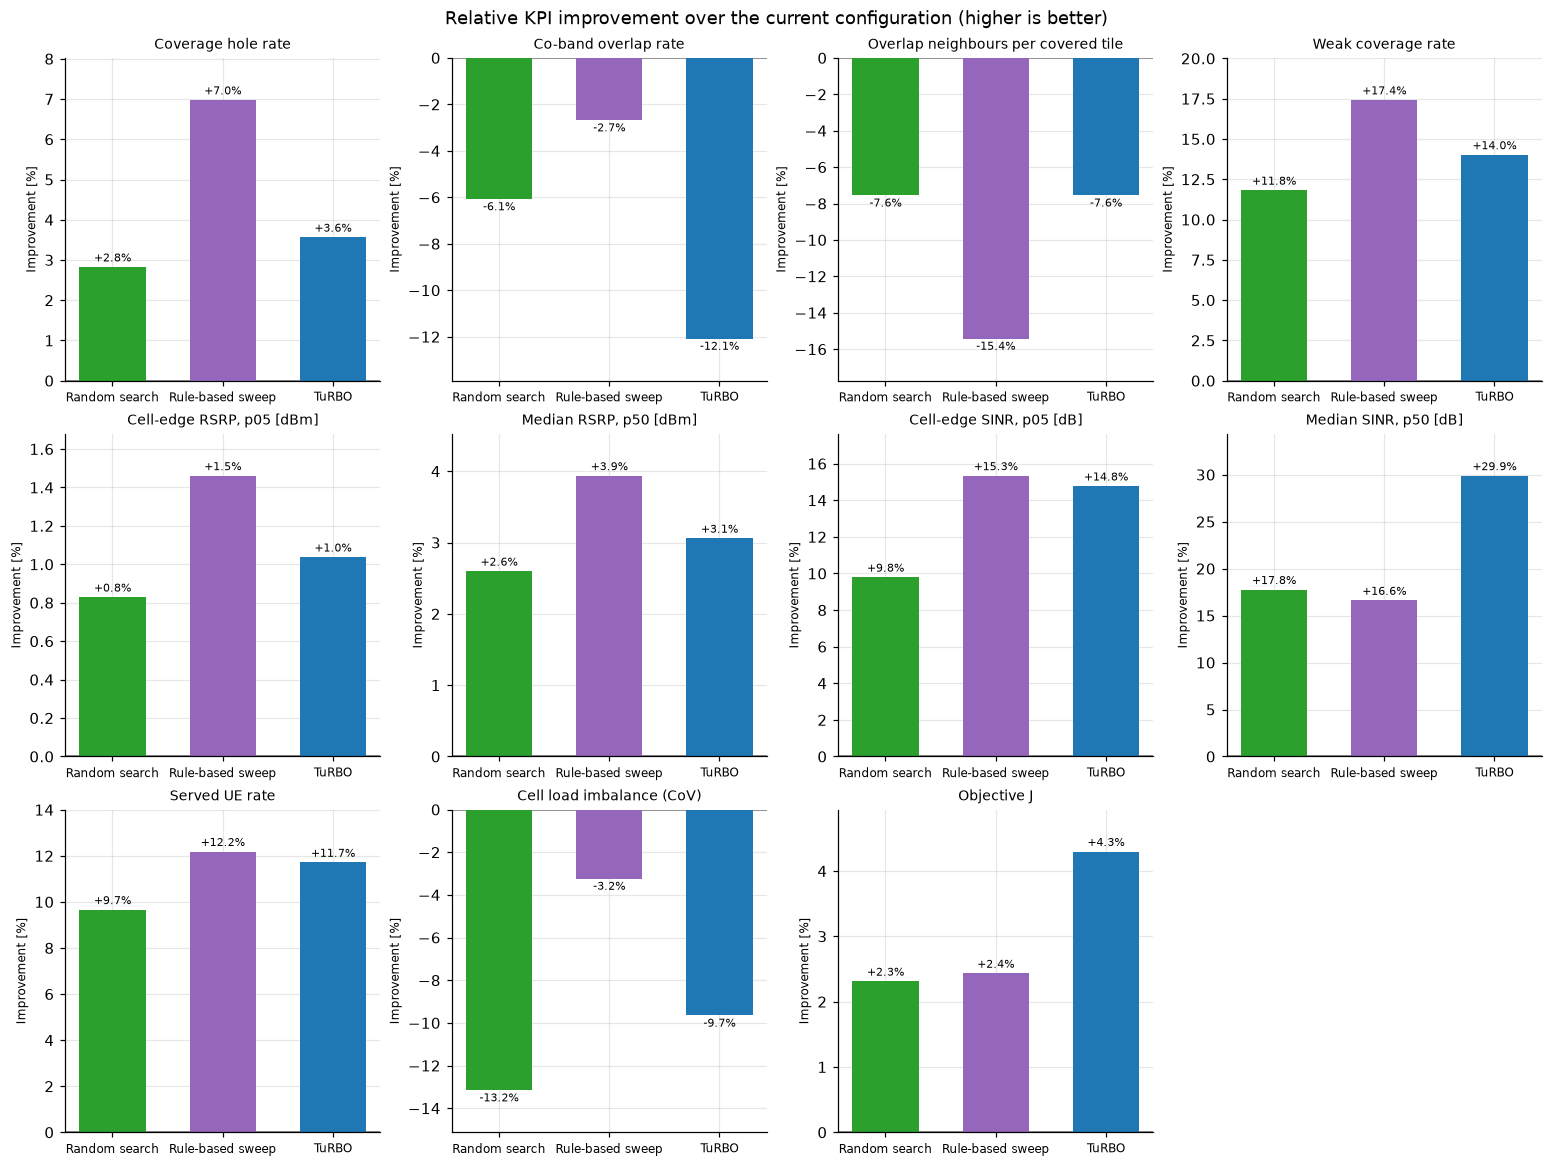

In [7]:
display(results["kpi_relative_improvement"])
display(results["kpi_improvement"])

**Observations.** TuRBO raises the objective most: **+4.32 % relative, 0.7333 to 0.7650**. The rule-based sweep gains +2.41 % and random search +2.31 %. On KPI counts TuRBO is 9 better and 2 worse; both baselines are 8 and 3.

$J$ is the share of the grid effectively covered - one dominant cell, at usable strength, on the tile's best band (ADR 0010). It is bounded in $[0, 1]$, has no free parameters and reads no demand map. None of these values compares with anything recorded before that change; the previous objective's incumbent was 0.8080 on a different scale.

**The objective and the KPI set now largely agree, and that is the change from the previous study.** TuRBO wins $J$, and the candidate with the best equal-weight rank score over the ten KPIs is also a TuRBO candidate, 0.0004 of $J$ below the one it picked. Head to head the rule sweep still takes 6 of the 10 KPIs to TuRBO's 4 - hole rate (0.1044 against 0.1082), weak rate (0.2538 against 0.2643), both RSRP percentiles and the served rate (0.5930 against 0.5821) - but TuRBO takes both SINR measures, overlap neighbours per covered tile, and cell load imbalance. Under the previous objective the split was 10 to 1.

Measured directly: over random search's 145 Sobol candidates, Spearman's rho between $J$ and that rank score is **0.902**, against **0.428** for the objective this replaced.

**Two measures still move the wrong way under every method.** The band-collapsed **co-band overlap rate** rises (0.3164 to 0.3356, 0.3247 and 0.3600) and **overlap neighbours per covered tile** rises with it. Section 11 shows that per band, overlap *improves* on 2600 MHz under all three and on 700 MHz under TuRBO; the union rises because newly covered tiles arrive at the edge of two footprints. This is the one place the new objective tracks the KPIs *worse* than the old one: rho against the overlap rate fell from 0.347 to 0.251, because a crowded band costs nothing when another band at the same tile is clean.

**Cell load imbalance improves under TuRBO** (0.9098 to 0.8818, +3.08 %), the first time any method has moved it in the right direction. Nothing in $J$ asks for even load, so this is a by-product of moving traffic off the most contended layer, not a result the objective bought.

## 7. Optimization Convergence

Best objective found so far against the number of evaluations, the current configuration being evaluation 0. The
band is the min–max over seeds and collapses to the line with one seed.

The second table asks whether the search mattered: each winner against the typical candidate its own search evaluated.

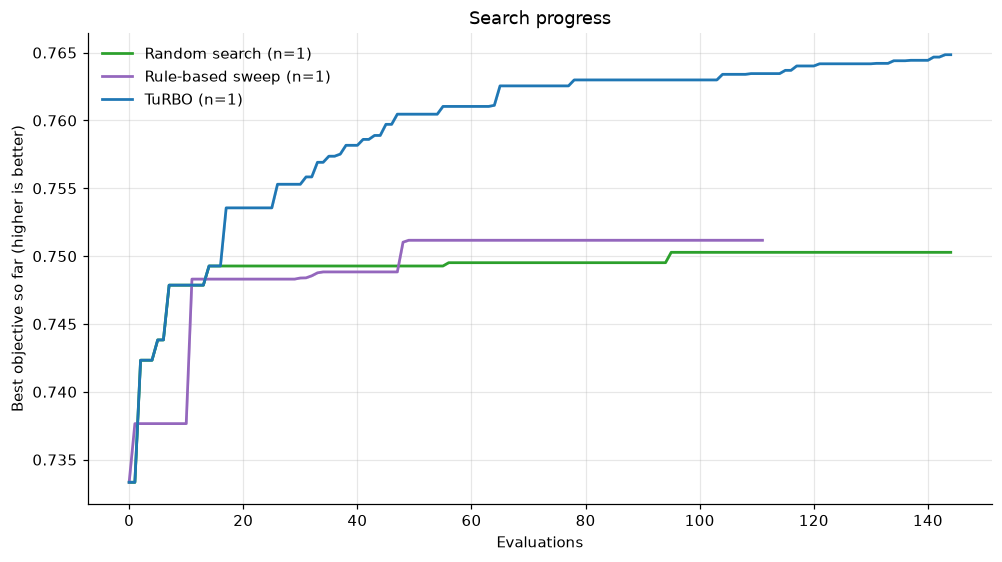

,Method,Seed,Current configuration,"Initial design, median objective","All candidates, median objective","All candidates, 90th percentile objective",Best objective found
0,Random search,42,0.7333,0.7365,0.7367,0.7455,0.7503
1,Rule-based sweep,42,0.7333,NaN,0.7467,0.7504,0.7512
2,TuRBO,42,0.7333,0.7365,0.7605,0.7640,0.7648


In [8]:
display(results["search_progress"])
display(results["winner_vs_candidates"])

**Observations.** TuRBO's median candidate (0.7606) scores above the rule sweep's best (0.7510) and random search's best (0.7503), and its 90th percentile is 0.7646. The trust region spends its budget near good configurations. Random search's candidates sit around their Sobol design median (0.7365) - *above* the current configuration's 0.7333, so the committed per-band tilts are a slightly weak starting point rather than a strong one - and it found its best at evaluation 95. The rule sweep's median candidate (0.7426) is high because it only moves whole bands around the current tilts, so it never visits a bad region.

TuRBO and random search share the same 16 Sobol points and diverge only once the model starts proposing: the shared design's median is 0.7365 for both, while TuRBO's all-candidate median is 0.7606 against random search's 0.7367.

## 8. Sample Efficiency

Best value reached after a fixed number of evaluations, averaged over seeds. Each KPI is its own running best, so the
rows of one budget need not come from one configuration. The last budget is the longest run; a budget past a run's
length is empty.

In [9]:
display(results["sample_efficiency"])

,KPI,Evaluations,Random search,Rule-based sweep,TuRBO
0,Objective J,10,0.7479,0.7377,0.7479
1,Objective J,25,0.7493,0.7483,0.7536
2,Objective J,50,0.7493,0.7512,0.7605
3,Objective J,100,0.7503,0.7512,0.7630
4,Objective J,145,0.7503,NaN,0.7648
5,Coverage hole rate,10,0.1083,0.1114,0.1083
6,Coverage hole rate,25,0.1083,0.1042,0.1083
7,Coverage hole rate,50,0.1082,0.1042,0.1082
8,Coverage hole rate,100,0.1082,0.1042,0.1081
9,Coverage hole rate,145,0.1082,NaN,0.1079


**Observations.** TuRBO reaches J = 0.7576 after 25 evaluations, already above the rule sweep's final 0.7510, and keeps improving to 0.7595 by 50, 0.7644 by 100 and 0.7650 at 145, finding its best at evaluation 143. **Unlike the previous study, there is no budget at which the sweep is the better answer** - the sweep's best is beaten by evaluation 25. Random search reaches 0.7493 by evaluation 25 and only improves once more, to 0.7503 at evaluation 95.

The running-best overlap rate still tells a blunter story: no candidate of any method improves much on the incumbent's 0.3164, and every winner ends above it. Overlap is the one dimension this objective still does not price well.

## 9. Multi-Objective Trade-Offs and Pareto Fronts

Each point is one evaluated configuration. The stars mark each method's highest-$J$ configuration, the
cross marks the current configuration, and the dashed line joins the Pareto-efficient configurations over all methods:
those that no other configuration beats on both axes at once.

The served UE ratio takes the place of the template's band-priority axis, which is not used in this project.

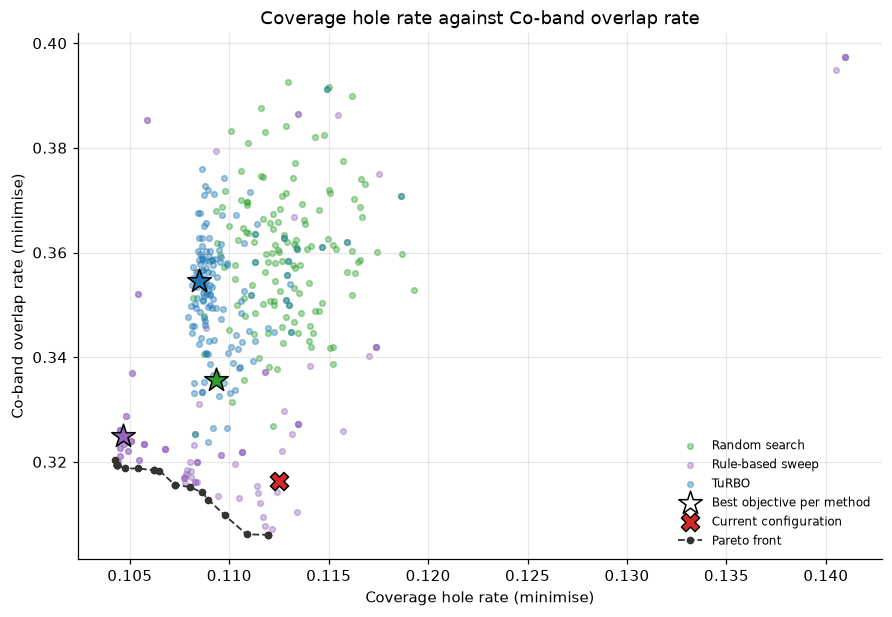

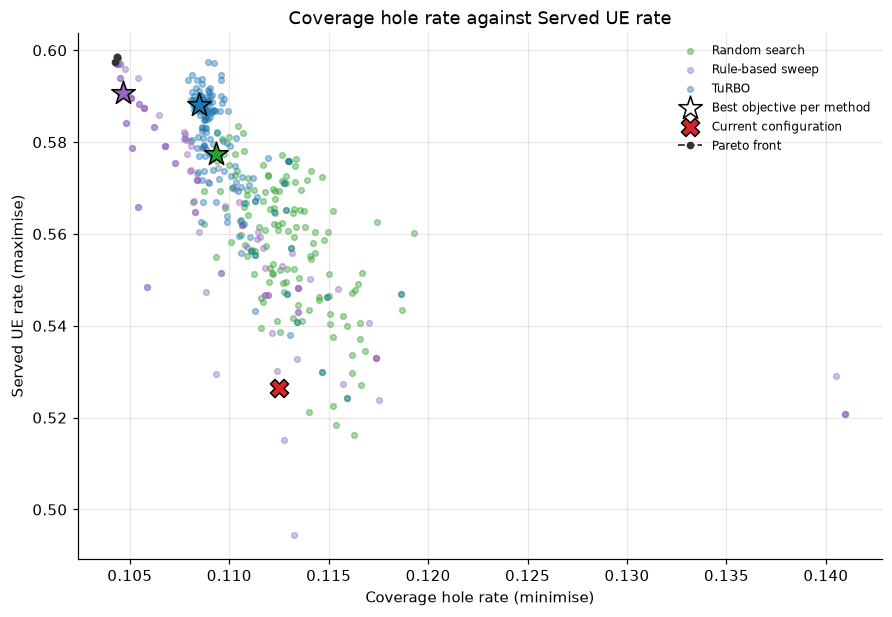

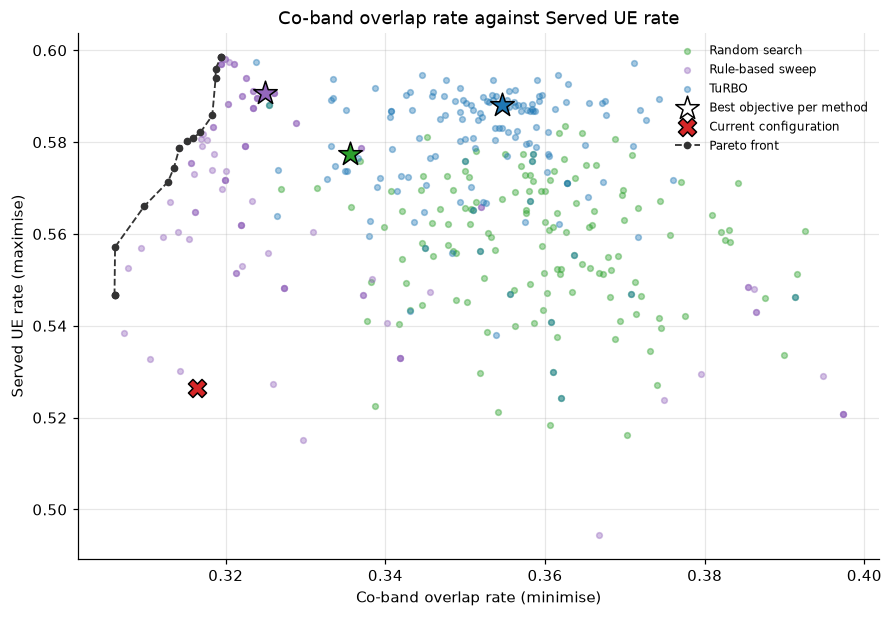

In [10]:
display(results["tradeoff_hole_rate_vs_overlap_rate"])
display(results["tradeoff_hole_rate_vs_served_rate"])
display(results["tradeoff_overlap_rate_vs_served_rate"])

**Observations.** Hole rate and overlap rate still conflict along the Pareto front, but not at the rate ADR 0009 set. Splitting a clean strong tile costs the full 0.264, while a newly covered tile arrives near $T_{\text{hole}}$ where the strength factor is near zero and is worth about 0.09 on this run - so **one newly crowded strong tile costs roughly three closed holes**, the reverse of the old objective's 3.78-to-1 in favour of holes. All three picks sit above the current configuration's overlap rate of 0.3164 - the sweep at 0.3247, random search at 0.3356 and TuRBO at 0.3600 - and TuRBO, which closes fewest holes of the three relative to its gain, sits highest.

Against the served rate all three picks sit close together near 0.58-0.59, because the served rate is bounded by the 0.8 admission ceiling rather than by coverage, so it cannot be traded far in either direction.

## 10. Spatial Coverage Analysis

### 11.1 Change in best-server RSRP per method

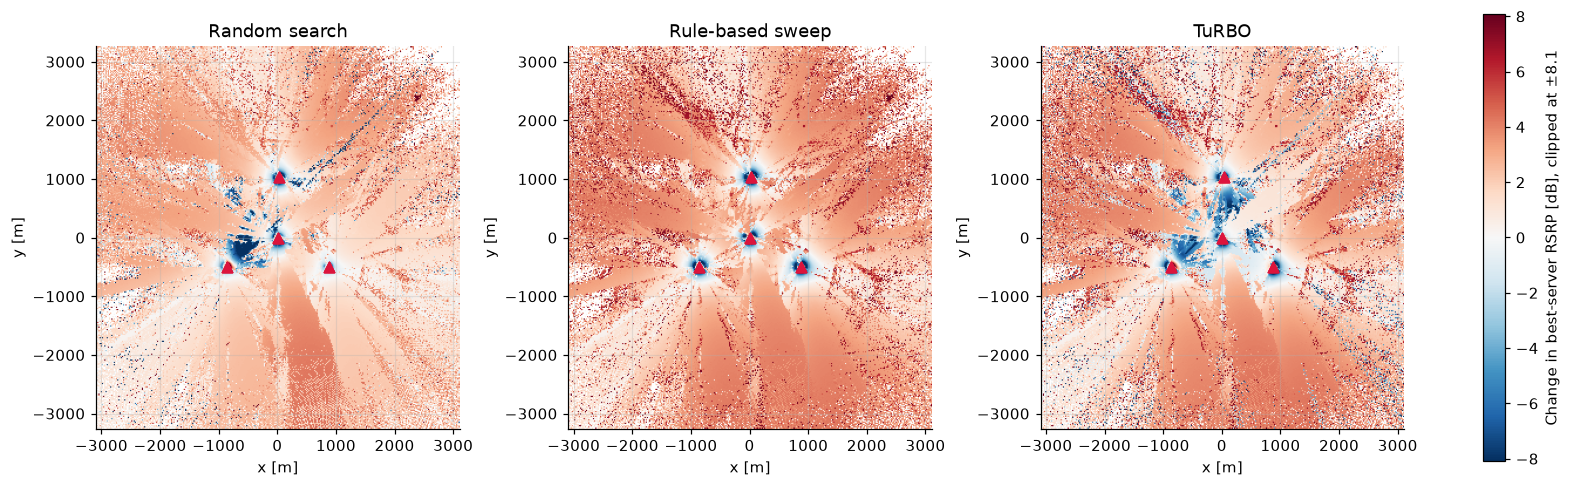

In [11]:
display(results["rsrp_change_maps"])

### 10.2 Before and after: the recommended configuration

The recommended configuration is the run with the highest objective over all methods. Both panels use the same scale
and the same coverage classes.

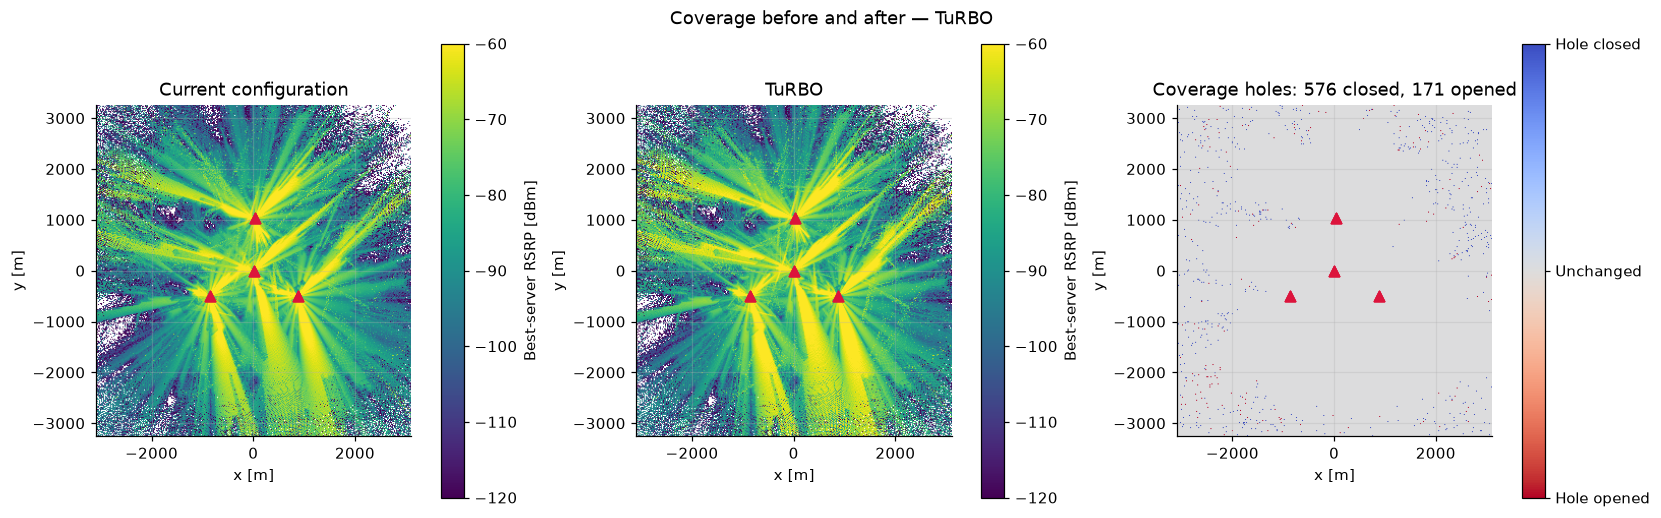

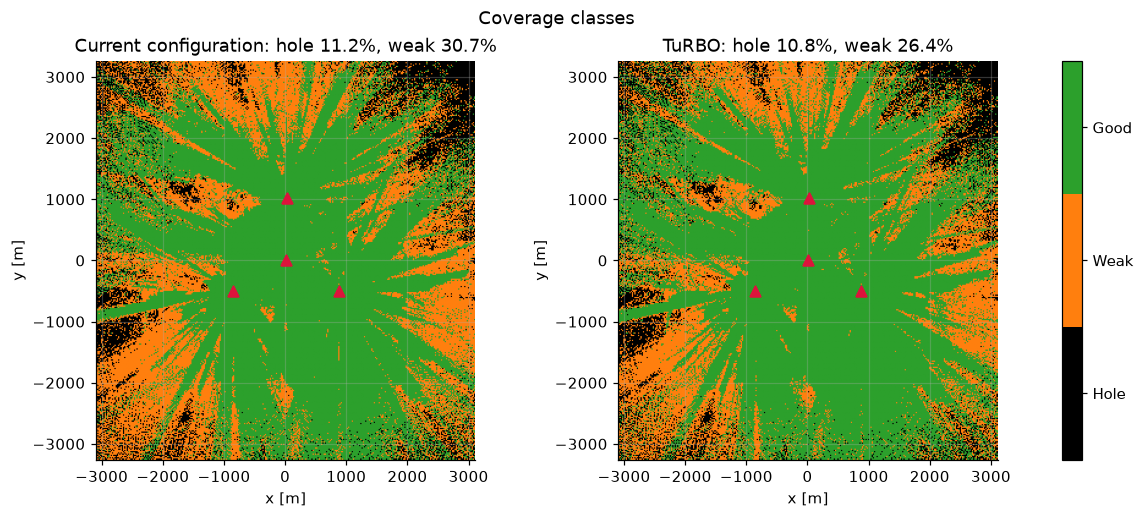

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand,TuRBO: Share of area,TuRBO: Share of demand
0,hole,0.1125,0.000,0.1093,0.0035,0.1046,0.0000,0.1085,0.0099
1,weak,0.3069,0.836,0.2707,0.7916,0.2535,0.7675,0.2639,0.7809
2,good,0.5806,0.164,0.6200,0.2049,0.6419,0.2325,0.6276,0.2093


In [12]:
display(results["coverage_before_after"])
display(results["coverage_class_maps"])
display(results["coverage_by_area_and_demand"])

### 10.3 Overlap neighbours

,Configuration,"Mean overlap neighbours, covered tiles","Mean overlap neighbours, all tiles",Share with 0 neighbours,Share with 1 neighbour,Share with 2 neighbours,Share with 3+ neighbours
0,Current configuration,0.9625,0.8543,0.6435,0.1127,0.0677,0.1761
1,Random search,1.0352,0.9221,0.6232,0.1300,0.0861,0.1606
2,Rule-based sweep,1.1110,0.9947,0.6372,0.1098,0.0749,0.1782
3,TuRBO,1.0352,0.9229,0.6022,0.1678,0.0823,0.1476


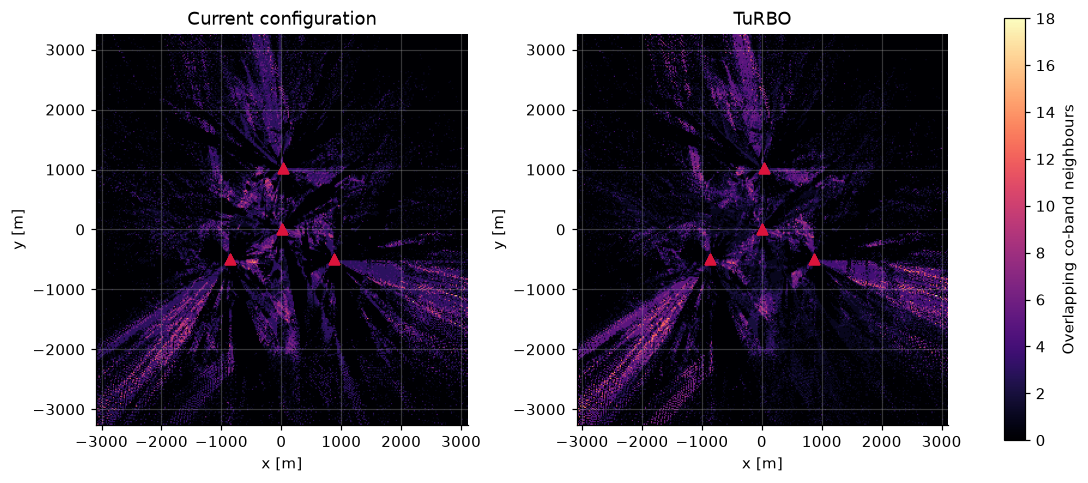

In [13]:
display(results["overlap_neighbour_summary"])
display(results["overlap_neighbour_maps"])

**Observations.** The recommended TuRBO configuration improves coverage by area on every class: holes 11.2 % to 10.8 %, weak 30.7 % to 26.4 %, good 58.1 % to 62.8 %. Weighted by where the served traffic stands, the share on weak tiles falls from 83.6 % to 78.5 % and the share on good tiles rises from 16.4 % to 20.9 %, while 0.6 % of demand lands on hole tiles where none did before. Nothing in the objective reads that demand view - ADR 0010 deleted the weighting - so it is a check on the result rather than a reflection of it, and this is the check finding something.

Overlap neighbours move two ways at once. The share of covered tiles with **three or more** neighbours falls from 17.6 % to 15.4 %, the best of the three methods - the worst pile-ups thin out. But the share with **no** neighbour also falls, 64.4 % to 59.6 %, and the mean over covered tiles rises from 0.963 to 1.034, because the tiles TuRBO newly covers arrive at the edge of two footprints and carry a neighbour with them.

That is the shape of $\lambda e^{1-\lambda}$: the penalty is steepest between one and three contending cells and nearly flat beyond four, so the objective will convert a few badly contested tiles into many mildly contested ones. The rule sweep, which has no per-cell freedom to do this, raises the mean further (to 1.120) and thickens the pile-ups instead (17.6 % to 17.9 %).

## 11. Frequency-Layer Analysis

Per band: the area the band covers above the hole threshold and its mean RSRP there, the area the serving rule assigns
to it, and the share of UE reports actually admitted on it after PRB limits, with their median SINR. The band preference
of the serving rule is `kpi.capacity.band_preference`.

Then every KPI of section 4 again, per layer. The `all` row is the whole radio map and equals the scoreboard above; a
band row is the same function given that band's layers, so nothing is redefined. The per-band served rates are shares
of *all* reports and so sum to the `all` row; the rates over tiles do not sum to anything, because a tile can be a hole
on two bands at once. There is no per-band objective: $J$ scores a network, and one layer of a multi-band network is
not a network.

,Configuration,Band,Share of area covered by the band,Mean band RSRP where covered [dBm],Share of area served on the band,Share of UE reports served on the band,"Served SINR on the band, median [dB]"
0,Current configuration,2600 MHz,0.7116,-97.1547,0.7116,0.3408,3.4679
1,Current configuration,1800 MHz,0.7650,-91.4508,0.0584,0.1050,5.1757
2,Current configuration,700 MHz,0.8619,-84.2119,0.1176,0.0807,13.3089
3,Random search,2600 MHz,0.7377,-92.3895,0.7377,0.4360,5.9189
4,Random search,1800 MHz,0.7700,-90.2628,0.0396,0.0584,4.5407
5,Random search,700 MHz,0.8641,-82.4724,0.1133,0.0830,13.5529
6,Rule-based sweep,2600 MHz,0.7354,-93.1135,0.7354,0.4270,5.8602
7,Rule-based sweep,1800 MHz,0.7830,-87.3601,0.0537,0.0898,5.6666
8,Rule-based sweep,700 MHz,0.8675,-81.7725,0.1063,0.0739,13.2816
9,TuRBO,2600 MHz,0.7241,-94.3496,0.7241,0.3448,5.2793


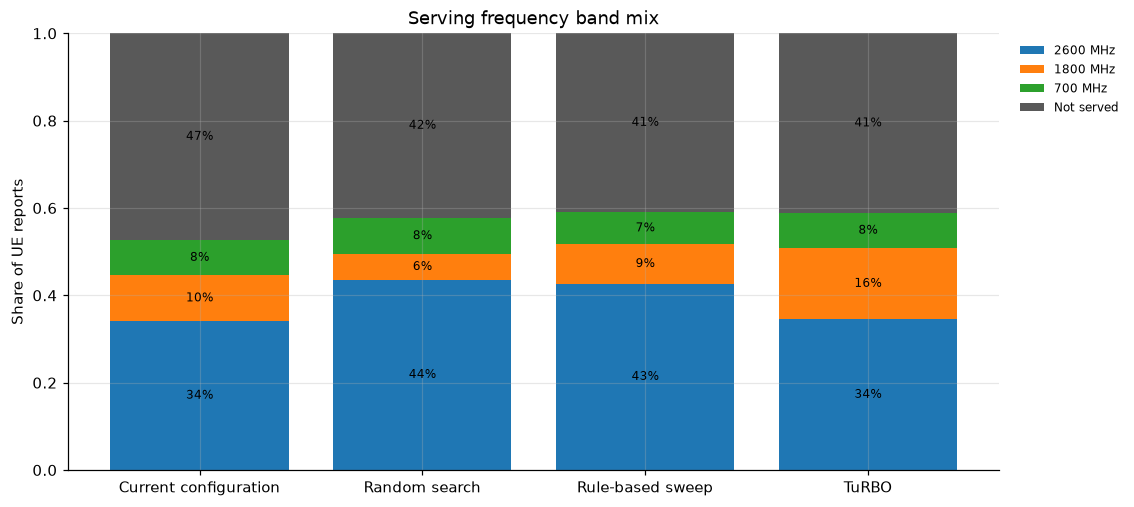

,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10087.0,0.4735,-0.3751,5.1257,53.1831,0.3408,0.1050,0.0807
1,Random search,10087.0,0.4226,0.1140,7.2168,41.9586,0.4360,0.0584,0.0830
2,Rule-based sweep,10087.0,0.4093,0.1694,6.8066,43.8404,0.4270,0.0898,0.0739
3,TuRBO,10087.0,0.4118,-0.6494,8.3111,37.5448,0.3448,0.1636,0.0798


,Configuration,Band,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,prb_utilisation_max,Cell load imbalance (CoV)
0,Current configuration,All bands,0.1125,0.3164,0.9625,0.3069,-108.5644,-84.1068,-5.8729,8.4932,0.5265,0.7999,0.9098
1,Current configuration,2600 MHz,0.2884,0.2010,0.3703,0.5124,-115.4094,-98.0890,-17.5911,-1.6299,0.3408,0.7999,0.6775
2,Current configuration,1800 MHz,0.2350,0.2067,0.3564,0.4171,-112.4538,-91.7208,-11.6703,4.1494,0.1050,0.7994,0.6074
3,Current configuration,700 MHz,0.1381,0.2396,0.3691,0.2945,-108.5333,-83.9182,-5.2264,8.3972,0.0807,0.7991,0.9986
4,Random search,All bands,0.1093,0.3356,1.0352,0.2707,-107.6647,-81.9227,-5.2979,10.0014,0.5774,0.8000,1.0295
5,Random search,2600 MHz,0.2623,0.1967,0.3751,0.4096,-113.8363,-92.1310,-16.0225,2.2893,0.4360,0.8000,0.6055
6,Random search,1800 MHz,0.2300,0.2065,0.3777,0.3915,-112.0833,-90.3290,-11.2946,4.7330,0.0584,0.7991,0.8739
7,Random search,700 MHz,0.1359,0.2304,0.4103,0.2619,-107.6910,-81.9399,-4.7425,9.6959,0.0830,0.7991,1.1481
8,Rule-based sweep,All bands,0.1046,0.3249,1.1110,0.2535,-106.9787,-80.7966,-4.9723,9.9037,0.5907,0.7999,0.9393
9,Rule-based sweep,2600 MHz,0.2646,0.1904,0.3371,0.4323,-114.2971,-93.4405,-16.4887,1.6919,0.4270,0.7999,0.5923


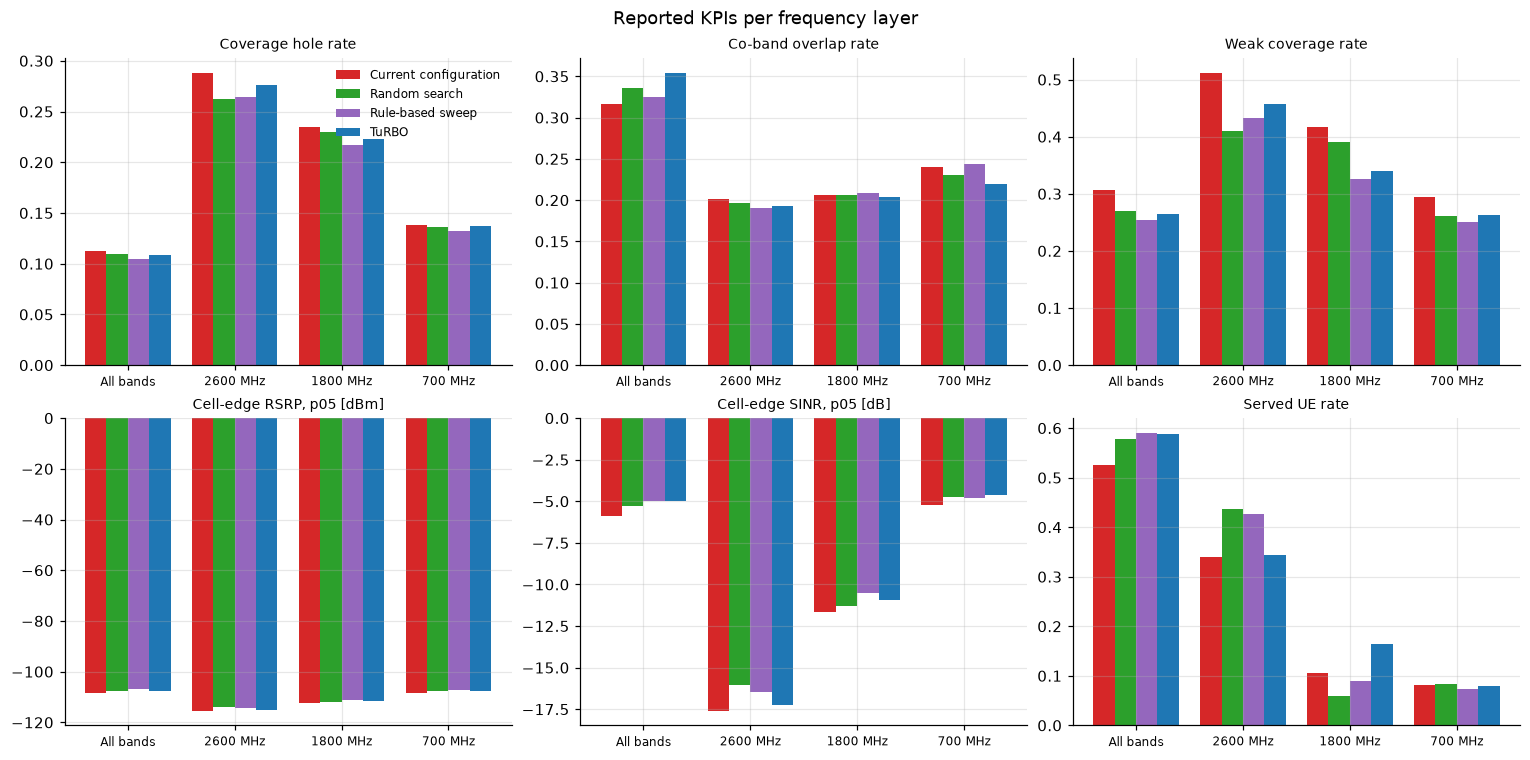

In [14]:
display(results["band_layer_summary"])
display(results["serving_band_mix"])
display(results["ue_service_summary"])
display(results["band_kpis"])
display(results["band_kpi_panels"])

**Observations.** The per-band rows are the point of a multi-band study, and they say something the whole-network row cannot: **no single layer covers the area**. Alone, 2600 MHz leaves 28.8 % of tiles as holes, 1800 MHz 23.5 % and 700 MHz 13.8 %, against 11.2 % for the union. The layers are complementary, not redundant, and that is the premise the project rests on.

**The objective now reads every layer, not one per tile.** Under ADR 0010 each band is scored on its own and the tile takes its best, so a tilt on any of the 36 cell-bands moves $J$ wherever that layer is the best one. The per-band overlap rows show the effect: 2600 MHz falls under every method (0.2010 to 0.1914 under TuRBO, 0.1901 under the sweep, 0.1967 under random search) and **700 MHz falls under TuRBO too** (0.2396 to 0.2224), where under the previous objective the two unscored layers drifted worse under all three. 1800 MHz is flat. The band-collapsed rate in the scoreboard still rises, because it is the union of all three plus the newly covered ground.

Per-band hole rates improve everywhere: 1800 MHz 0.235 to 0.223 under TuRBO, 2600 MHz 0.288 to 0.279 and 700 MHz 0.138 to 0.136.

**The serving mix is where TuRBO parts company with the baselines.** Both baselines push UE reports onto the preferred 2600 MHz layer (34.1 % to 43.6 % and 43.8 %). TuRBO lifts it only to 35.7 % and raises **1800 MHz from 10.5 % to 14.6 %** instead. The payoff is the best service quality of the three: median PRBs per served UE fall from 53.2 to 39.7 and median served SINR rises from 5.1 to 7.8 dB, because traffic moved off the most contended layer. The 10th-percentile served SINR is slightly *worse* than either baseline's, though (-0.18 dB against +0.11 and +0.25), so the gain sits in the middle of the distribution and not at the edge.

Every band in every configuration peaks at about 0.8 of its PRB limit, the admission ceiling, so no layer has headroom. That figure is the check that the serving rule held; ADR 0010 dropped it from the KPI set because it cannot be anything else.

## 12. Cell Load and PRB Usage

Peak PRB utilisation and the load-imbalance KPI are reductions of one series: the PRBs each cell-band carried in each 15-minute interval, as a share
of its own limit. The heatmap is that series; the table beside it is the per-cell-band summary the utilisation figure
is drawn from.

The serving rule refuses any admission that would carry a cell-band past `kpi.capacity.max_admission_utilisation`, so
no cell can appear above the ceiling. A cell *at* the ceiling is one that turned traffic away, and that traffic shows
up in the served rate, not here.

Peak PRB utilisation is **not** among the reported KPIs (ADR 0010): being bounded by the ceiling by construction, it
never varied by more than 0.002 across the previous study's 318 candidates. It is printed here as the check that the
admission rule held - anything above 0.8 is a fault - and it is not scored.

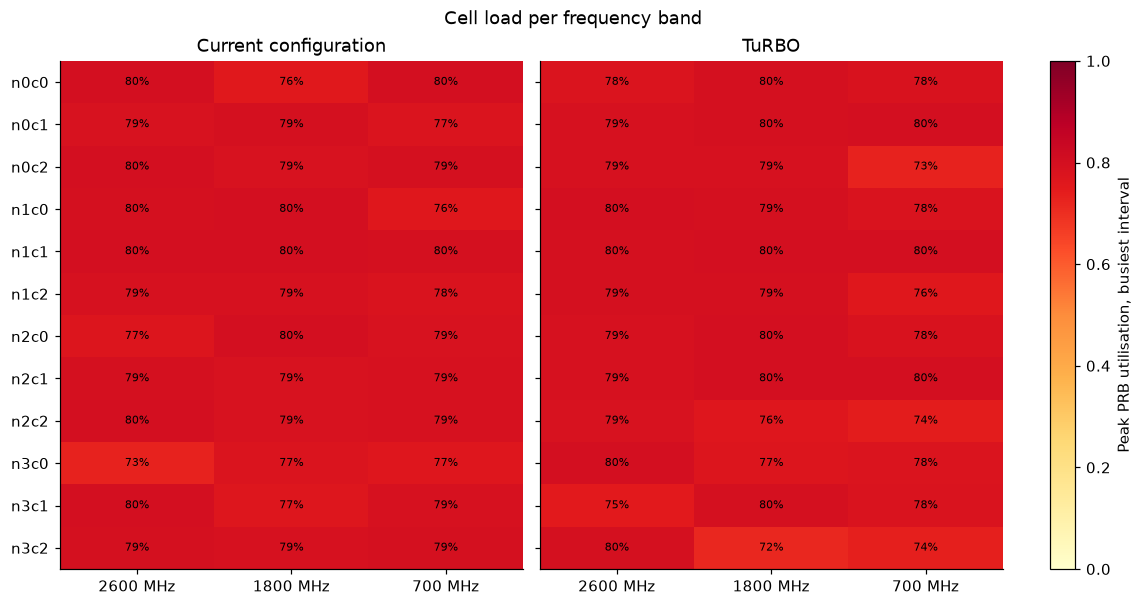

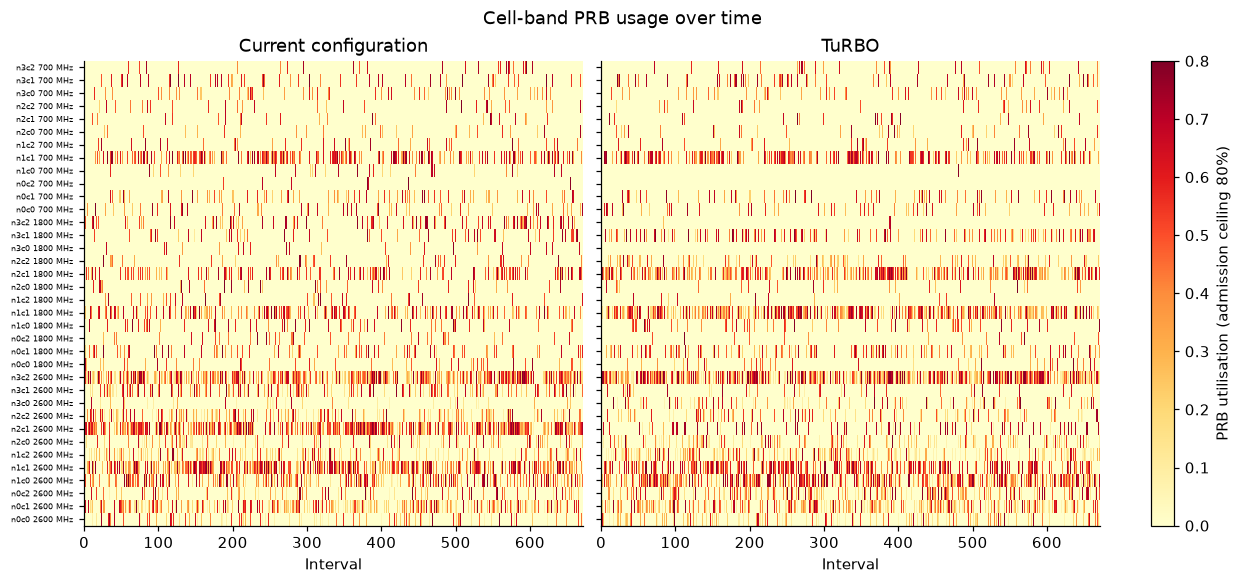

,Cell,Band,Served reports,Mean PRB load,Peak PRB load,PRB limit,Median SINR [dB],Peak PRB utilisation,Configuration
0,n0c0,2600 MHz,123,12.6004,172.1595,216.0,3.9552,0.7970,Current configuration
1,n0c1,2600 MHz,389,31.6248,170.0246,216.0,8.1041,0.7872,Current configuration
2,n0c2,2600 MHz,103,13.0561,172.7687,216.0,2.1295,0.7999,Current configuration
3,n1c0,2600 MHz,276,37.9955,171.7453,216.0,1.2829,0.7951,Current configuration
4,n1c1,2600 MHz,538,63.5284,172.7813,216.0,2.7273,0.7999,Current configuration
...,...,...,...,...,...,...,...,...,...
31,n2c1,700 MHz,31,1.4008,41.4884,52.0,10.8049,0.7979,TuRBO
32,n2c2,700 MHz,31,1.0554,38.6789,52.0,15.7533,0.7438,TuRBO
33,n3c0,700 MHz,67,2.0391,40.3908,52.0,17.1407,0.7767,TuRBO
34,n3c1,700 MHz,79,3.4527,40.5469,52.0,9.7772,0.7797,TuRBO


,Configuration,Cell,Band,Interval,PRB load,PRB utilisation
0,Current configuration,n1c1,2600 MHz,295,172.7813,0.7999
1,Current configuration,n0c2,2600 MHz,442,172.7687,0.7999
2,TuRBO,n3c0,2600 MHz,368,172.7659,0.7998
3,Current configuration,n2c2,2600 MHz,204,172.7200,0.7996
4,TuRBO,n1c1,1800 MHz,220,84.7485,0.7995
5,TuRBO,n1c0,2600 MHz,165,172.6818,0.7995
6,Current configuration,n2c0,1800 MHz,131,84.7339,0.7994
7,TuRBO,n0c1,700 MHz,283,41.5536,0.7991
8,Current configuration,n0c0,700 MHz,409,41.5521,0.7991
9,TuRBO,n2c1,1800 MHz,250,84.6884,0.7989


In [15]:
display(results["cell_band_utilisation"])
display(results["prb_usage_heatmaps"])
display(results["cell_band_load"])

# 48k rows is a series, not a table; show where it runs hottest.
usage = results["prb_usage_by_time"]
busiest = (
    usage.sort_values("PRB utilisation", ascending=False)
    .drop_duplicates(["Configuration", "Cell", "Band"])
    .head(10)
    .reset_index(drop=True)
)
display(busiest)

## 13. Tilt Configuration Analysis

$$
\Delta\theta_{i,b} = \theta^{*}_{i,b} - \theta^{(0)}_{i,b}
$$

for the recommended configuration. Negative is uptilt. The cell impact table is sorted by how much traffic each
cell-band gained or lost, so the cells to watch after rollout come first.

,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,8.4704,-3.5296,0.0,15.0
1,n0c0,1800 MHz,10.0,0.6085,-9.3915,0.0,15.0
2,n0c0,700 MHz,8.0,4.7035,-3.2965,0.0,15.0
3,n0c1,2600 MHz,12.0,10.7770,-1.2230,0.0,15.0
4,n0c1,1800 MHz,10.0,2.5354,-7.4646,0.0,15.0
5,n0c1,700 MHz,8.0,1.9253,-6.0747,0.0,15.0
6,n0c2,2600 MHz,12.0,4.6089,-7.3911,0.0,15.0
7,n0c2,1800 MHz,10.0,3.1075,-6.8925,0.0,15.0
8,n0c2,700 MHz,8.0,13.4858,5.4858,0.0,15.0
9,n1c0,2600 MHz,12.0,1.4751,-10.5249,0.0,15.0


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,7.5267,9.8734,-6.3571
1,2600 MHz,12,12,5.4688,11.7282,-4.1267
2,700 MHz,12,12,5.1795,7.7384,-2.9869


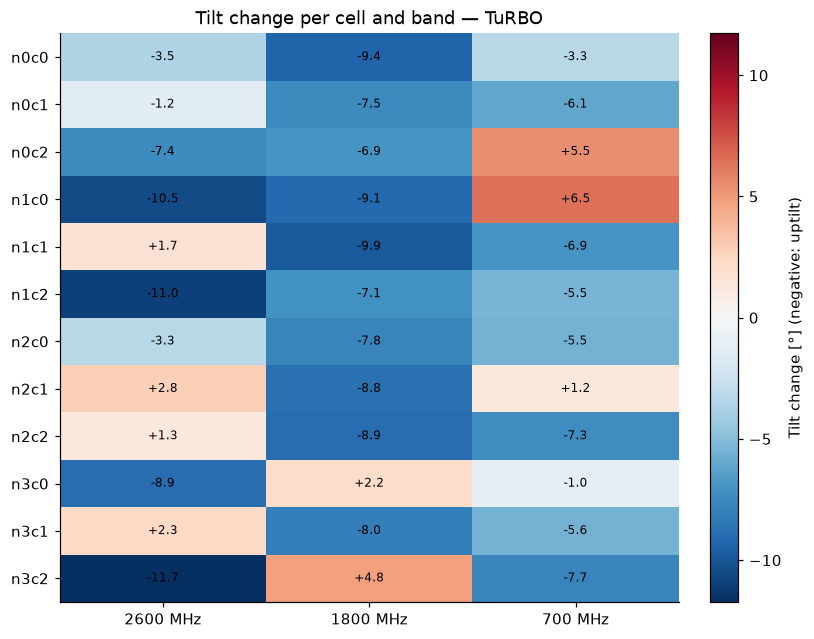

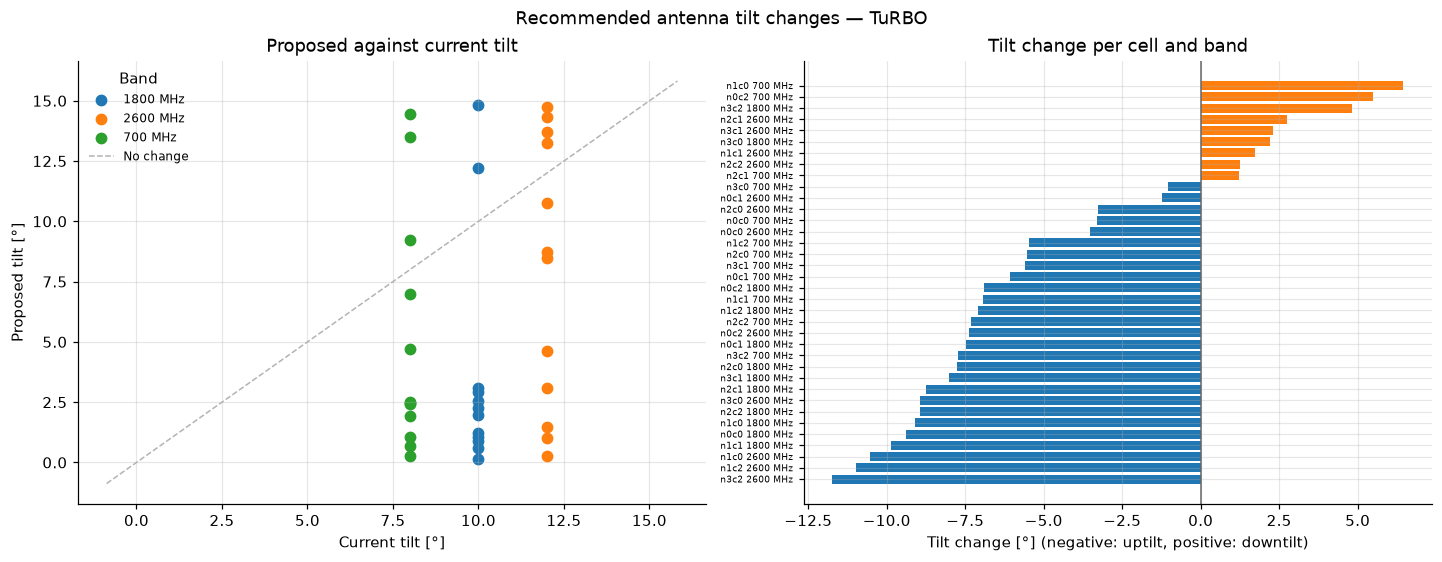

,Node,Cell,Azimuth [°],Band,Current tilt [°],Proposed tilt [°],Tilt change [°],"Served reports, before","Peak PRB utilisation, before",Median SINR before [dB],"Served reports, after","Peak PRB utilisation, after",Median SINR after [dB],"Served reports, change","Peak PRB utilisation, change",Median SINR change [dB]
0,n2,n2c1,165.0,2600 MHz,12.0,14.7604,2.7604,562,0.7946,2.1302,92,0.7920,-1.6827,-470,-0.0026,-3.8129
1,n3,n3c2,285.0,2600 MHz,12.0,0.2718,-11.7282,652,0.7944,4.9970,1009,0.7957,10.5438,357,0.0013,5.5467
2,n1,n1c1,165.0,1800 MHz,10.0,0.1266,-9.8734,258,0.7986,8.2267,597,0.7995,13.8230,339,0.0009,5.5962
3,n2,n2c1,165.0,1800 MHz,10.0,1.2384,-8.7616,165,0.7873,4.8821,434,0.7989,9.1836,269,0.0116,4.3015
4,n1,n1c1,165.0,2600 MHz,12.0,13.7206,1.7206,538,0.7999,2.7273,297,0.7955,-0.7470,-241,-0.0044,-3.4743
5,n1,n1c0,45.0,2600 MHz,12.0,1.4751,-10.5249,276,0.7951,1.2829,503,0.7995,3.6893,227,0.0043,2.4064
6,n3,n3c1,165.0,2600 MHz,12.0,14.3136,2.3136,199,0.7975,0.7477,41,0.7508,-0.5717,-158,-0.0467,-1.3194
7,n0,n0c2,285.0,2600 MHz,12.0,4.6089,-7.3911,103,0.7999,2.1295,237,0.7893,3.0556,134,-0.0105,0.9262
8,n3,n3c2,285.0,1800 MHz,10.0,14.8191,4.8191,125,0.7894,3.3770,4,0.7158,2.6591,-121,-0.0735,-0.7179
9,n3,n3c1,165.0,1800 MHz,10.0,1.9759,-8.0241,70,0.7683,4.6178,176,0.7954,5.2009,106,0.0271,0.5831


In [16]:
display(results["recommended_tilt"])
display(results["tilt_movement_summary"])
display(results["tilt_delta_heatmap"])
display(results["tilt_movement"])
display(results["cell_impact"])

**Observations.** Every one of the 36 cell-bands moved. 27 are uptilted and 9 downtilted, and the downtilts are spread across all three bands rather than confined to 2600 MHz as they were under the previous objective. Mean absolute changes are 7.94 deg on 1800 MHz, 5.41 deg on 2600 MHz and 4.59 deg on 700 MHz, with the largest single change 10.85 deg. Proposed tilts span 0.24 deg to 14.59 deg, so **both** bounds of the [0, 15] box are approached - unlike the rule sweep, which pins whole bands to one value.

The mean change is negative on every band (-6.67 deg on 1800 MHz, -3.83 deg on 2600 MHz, -2.98 deg on 700 MHz): the network as a whole is uptilted, widening footprints. That is what lifts the hole and weak rates, and it is also what brings new tiles into coverage carrying a neighbour, which is why the band-collapsed overlap rate rises.

The cell-impact table shows the trade cell by cell, and the clearest case is n2c1: its **2600 MHz carrier is downtilted 2.59 deg and loses 382 served reports** while its **1800 MHz carrier is uptilted 7.84 deg and gains 283** - the same sector handing traffic from the high band down to the mid band, with its median SINR moving -3.1 dB and +3.0 dB to match. n1c1 and n1c0 are the reverse case: 2600 MHz uptilted 8.5 and 10.2 deg, gaining 278 and 254 reports with median SINR up 7.6 and 3.1 dB. Those are the cells to watch after a rollout.

## 14. Computational Cost

The expensive part is ray tracing, which is summed over every evaluation, apart from algorithm overhead (the difference
to wall clock: GP fitting and acquisition for TuRBO, I/O for all).

In [17]:
cost = results["method_cost"][["Method", "Seed", "Evaluations", "Ray tracing [min]", "Wall clock [min]"]].copy()
cost["Ray tracing per evaluation [s]"] = cost["Ray tracing [min]"] * 60 / cost["Evaluations"]
cost["Overhead [min]"] = cost["Wall clock [min]"] - cost["Ray tracing [min]"]
display(cost)

,Method,Seed,Evaluations,Ray tracing [min],Wall clock [min],Ray tracing per evaluation [s],Overhead [min]
0,Random search,42,145,8.1022,11.2046,3.3526,3.1024
1,Rule-based sweep,42,112,4.4573,7.1058,2.3879,2.6485
2,TuRBO,42,145,9.2717,19.5851,3.8366,10.3134


**Observations.** Ray tracing takes 3.5 s per evaluation for random search and 4.1 s for TuRBO, on the same 145-evaluation budget; the difference is solver variance, not method. TuRBO's GP fitting and acquisition add about 9 minutes on top of its 9.8 minutes of tracing, for 19.1 minutes in all against random search's 11.8. The rule sweep finished in 2.1 minutes. Unlike the previous study, the cheap method no longer competes on quality: TuRBO passes the sweep's final objective by evaluation 25 and ends 0.0140 of $J$ above it, so the sweep buys 56 % of TuRBO's gain for a ninth of the wall clock.

## 15. Key Results

The recommended TuRBO winner against the current configuration and the best baseline (highest objective among random
search and the rule-based sweep), every UE. The improvement column is TuRBO relative to the current configuration,
positive is better.

In [18]:
board = results["kpi_scoreboard"]
means = board.pivot(index="KPI", columns="Method", values="Mean")
current = board.drop_duplicates("KPI").set_index("KPI")["Current configuration"]
baselines = [m for m in means.columns if m != "TuRBO"]
best_baseline = means.loc["Objective J", baselines].idxmax()
improvement = results["kpi_relative_improvement"].set_index("Method").loc["TuRBO"]
order = list(dict.fromkeys(board["KPI"]))
key_results = pd.DataFrame(
    {
        "Current configuration": current,
        f"Best baseline ({best_baseline})": means[best_baseline],
        "TuRBO": means["TuRBO"],
        "TuRBO improvement [%]": improvement,
    }
).loc[order]
display(key_results)

,Current configuration,Best baseline (Rule-based sweep),TuRBO,TuRBO improvement [%]
Coverage hole rate,0.1125,0.1046,0.1085,3.5626
Co-band overlap rate,0.3164,0.3249,0.3546,-12.0813
Overlap neighbours per covered tile,0.9625,1.1110,1.0352,-7.5531
Weak coverage rate,0.3069,0.2535,0.2639,14.0149
"Cell-edge RSRP, p05 [dBm]",-108.5644,-106.9787,-107.4383,1.0372
"Median RSRP, p50 [dBm]",-84.1068,-80.7966,-81.5342,3.0587
"Cell-edge SINR, p05 [dB]",-5.8729,-4.9723,-5.0055,14.7687
"Median SINR, p50 [dB]",8.4932,9.9038,11.0308,29.8781
Served UE rate,0.5265,0.5907,0.5882,11.7115
Cell load imbalance (CoV),0.9098,0.9393,0.9976,-9.6532


### Main observations

* **Coverage:** TuRBO improves coverage on every area measure - hole rate -3.8 % relative, weak coverage -13.9 %, cell-edge RSRP +1.1 dB, median RSRP +2.6 dB. The rule sweep improves all four by more.
* **Effective coverage:** the quantity the objective is built from rises from 0.7333 to 0.7650, the best of the three and a +4.32 % gain against the baselines' +2.41 % and +2.31 %.
* **Overlap:** the band-collapsed co-band overlap rate *rises* under all three methods, most under TuRBO (0.3164 to 0.3600). Per band it falls on 2600 MHz under all three and on 700 MHz under TuRBO; 1800 MHz is flat. Pile-ups of three or more neighbours fall from 17.6 % to 15.4 % of covered tiles, the best of the three. **This is the measure the new objective tracks worst** - see the note below.
* **Signal quality:** median served SINR rises 2.6 dB under TuRBO (5.1 to 7.8), median PRBs per served UE fall 25 %, and both SINR percentiles are the best of the three. The 10th-percentile served SINR is the worst of the three, so the gain is in the middle of the distribution.
* **Band coordination:** TuRBO is the only method that grows the *mid* band - 1800 MHz from 10.5 % to 14.6 % of served reports, while lifting 2600 MHz only to 35.7 %. Both baselines push 2600 MHz to about 44 %. No layer covers the area alone (per-band hole rates 14-29 % against 11 % for the union).
* **Load:** every configuration sits at the 0.8 admission ceiling. Cell load imbalance *improves* under TuRBO (+3.08 %), the first time any method has moved it the right way, and worsens under both baselines. Nothing in the objective asks for it.
* **Optimization efficiency:** TuRBO passes the rule sweep's final objective by evaluation 25 and keeps improving to 145. There is no budget on which the sweep wins, unlike the previous study. Random search stalls after evaluation 95.
* **Objective versus KPIs:** they now largely agree. TuRBO wins $J$ and the best equal-weight KPI rank score in the study belongs to a TuRBO candidate 0.0004 of $J$ away. Head to head the sweep still wins 6 of the 10 KPIs to TuRBO's 4, against 10 to 1 under the previous objective.
* **Proxy quality:** Spearman's rho between $J$ and the equal-weight rank score over the ten KPIs, across random search's 145 Sobol candidates, is **0.902** against **0.428** for the objective ADR 0010 replaced. Per KPI it rose on eight of the ten and fell on the two overlap measures.
* **Robustness:** unknown, with one seed per method.

## 16. Figures for Presentation

All saved under `reports/figures/04_evaluation/`.

| # | Figure | File | Purpose |
|---|---|---|---|
| 1 | Overall KPI comparison | `kpi_improvement.png` | Direct comparison of every method's improvement |
| 2 | Optimization convergence | `search_progress.png` | Sample efficiency of the search |
| 3 | Hole–overlap trade-off | `tradeoff_hole_rate_vs_overlap_rate.png` | Coverage against overlap, with the Pareto front |
| 4 | Coverage before vs after | `coverage_before_after.png`, `coverage_class_maps.png` | Where coverage changed |
| 5 | Serving band distribution | `serving_band_mix.png` | Whether multi-band coordination behaves as intended |
| 6 | KPIs per frequency layer | `band_kpi_panels.png` | Whether each band plays the role its propagation suits |
| 7 | Cell-band PRB usage over time | `prb_usage_heatmaps.png` | Which cells run hot, and when |
| 8 | Tilt adjustment heatmap | `tilt_delta_heatmap.png` | What the optimizer decided |

## 17. Conclusions

1. **Holes:** yes. All three methods lower the hole rate (the sweep -7.2 % relative, TuRBO -3.8 %, random -2.8 %). Per band, every layer improves under every method.
2. **Co-band overlap:** **no, on the reported measure** - all three raise the band-collapsed rate (the sweep +2.6 %, random +6.1 %, TuRBO +13.8 %). Per band it is the reverse on the layers that matter: 2600 MHz falls from 0.2010 to 0.1914 (TuRBO), 0.1901 (sweep) and 0.1967 (random), and 700 MHz falls to 0.2224 under TuRBO. The collapsed rate rises because it is the union of three layers and because hundreds of newly covered tiles arrive with a neighbour already.

   **This is the one place ADR 0010 made things worse.** Because $J$ takes each tile's best band, a crowded layer costs nothing where another layer at the same tile is clean. Measured over the Sobol sample, rho between $J$ and the overlap rate fell from 0.347 to 0.251, and between $J$ and overlap neighbours per covered tile from 0.381 to 0.235 - the only two of the ten KPIs that the new objective tracks less well than the old. Pricing the non-serving layers' crowding is the first thing to revisit.
3. **Overlapping neighbours:** the mean per covered tile rises under every method (0.963 to 1.034 under TuRBO), but TuRBO cuts the worst pile-ups - three or more neighbours fall from 17.6 % to 15.4 % of covered tiles. That is the shape of $\lambda e^{1-\lambda}$: steep between one and three contending cells, nearly flat beyond four.
4. **Frequency layers:** the two baselines move served traffic onto the preferred 2600 MHz layer; **TuRBO spreads it**, raising 1800 MHz from 10.5 % to 14.6 % while lifting 2600 MHz only to 35.7 %. No layer covers the area alone.
5. **Load:** partly. Every configuration runs at the 0.8 admission ceiling, but cell load imbalance improves under TuRBO (0.9098 to 0.8818) for the first time in this study, while both baselines worsen it. Load is still reported, not optimised.
6. **Consistency across runs:** not measurable, with one seed per method.
7. **Evaluations needed:** TuRBO beats the rule sweep's final answer by evaluation 25 and keeps improving to 145, finding its best at evaluation 143 of 145. The sweep reaches its own result in 24.
8. **Tilt changes:** large and structured. All 36 cell-bands move, 27 uptilted and 9 downtilted across all three bands, the largest change 10.85 deg, and proposed tilts spanning 0.24 deg to 14.59 deg - so both ends of the [0, 15] box are in play. The mean change is negative on every band, so the network is uptilted overall.

**Final summary.** TuRBO achieved a 4.32 % higher objective than the current configuration (0.7333 to 0.7650 on the $[0, 1]$ scale of ADR 0010) while improving 9 of the 11 reported measures, and it found the multi-band strategy neither baseline reached: spread traffic across layers rather than concentrating it on the preferred one. Its margin over the three-variable rule sweep is now real rather than marginal - 0.7650 against 0.7510, and it passes the sweep's final answer after 25 of its 145 evaluations - though the sweep still delivers 56 % of the gain for a ninth of the wall clock and still wins 6 of the 10 individual KPIs.

**On the objective itself.** ADR 0010 was written because the previous objective was a weak proxy: Spearman's rho against the equal-weight KPI rank score was 0.428, TuRBO had *evaluated* the best-KPI configuration in that study and $J$ told it to pick another, and $J$ could be raised 7 % of the grid's worth by destroying coverage on a crowded preferred layer. On this run rho is **0.902**, the exploit surface measures **0.0000** on all three winner maps, and the gap between the best KPI score TuRBO evaluated and the one it picked fell from 0.11 to 0.037. The objective and the report card no longer disagree about the winner. The cost is recorded honestly in ADR 0010: $J$ no longer agrees with the serving rule about which band a tile belongs to, nothing is weighted by demand any more, inter-band interference is still priced nowhere, and the overlap KPIs are tracked worse than before.

None of these figures is comparable with anything recorded before 2026-09-20: the objective was replaced (ADR 0010), one KPI was dropped, and the demand map was deleted. The runs traced under the previous objective have been deleted rather than archived, and `kpi.objective_version` now refuses to pool scores across the change.

### Threats to validity

| # | Threat | Evidence | Status |
|---|---|---|---|
| 1 | One scenario: every configuration is tuned and scored on the same city and population, so no result measures generalisation | - | Open: held-out scenarios are not implemented |
| 2 | Winner's curse: the best of many evaluations under one solver seed is biased upward | Section 5, recomputed against recorded | Open: re-tracing under other solver seeds is notebook 03b only |
| 3 | Simple reference: the current configuration uses one tilt per band for every cell | Section 7, winner against candidates | Reported |
| 4 | One search seed per method: no spread, interval or test | Section 6, the scoreboard's blank CI columns | Open |
| 5 | The objective depends on judgement parameters | ADR 0010 | Closed: the objective has no parameters of its own. It reads `hole_dbm`, `weak_dbm` and `overlap_margin_db`, each of which a reported KPI already defines |
| 5b | The objective ignored signal strength above the hole threshold, so an effectively covered but marginal network scored full marks | ADR 0009, negative consequences | Closed by ADR 0010: the strength factor `s` scales every tile by where its server sits between `hole_dbm` and `weak_dbm`. The new exposure is the reverse - `J` and `weak_rate` are no longer independent readings |
| 5c | The objective could be raised by destroying coverage: `lambda` was counted on whichever band the tilts left standing | ADR 0010, context; 7.0-7.6 % of the grid worth +0.024 to +0.027 of `J` on the previous winners | Closed by ADR 0010: `J` takes the maximum over bands, which no removal can raise |
| 5d | The objective's functional form is in code, not in config, so the comparability check cannot see a change to it | ADR 0010; `src/evaluation/runs.py` | Mitigated: `kpi.objective_version` is bumped by hand and compared against the running config as well as run to run. It is still a manual step |
| 6 | The objective was described as demand-weighted while the weight did almost nothing | ADR 0010, context: `r = 0` on 97.0 % of tiles, mean `w` 1.0035, `J` moved by 0.0005 | Closed by ADR 0010: the demand map is deleted and `J` is tile-uniform. The cost is that nothing optimises for where the traffic stands, which is now threat 7 entire |
| 7 | Every score counts area, including area without users. Nothing in the search knows where the traffic stands | Section 10.2, coverage by area and by demand | Open, and widened by ADR 0010 |
| 8 | The served rate, the load imbalance KPI and the PRB ceiling check rely on placeholder capacity settings | `configs/kpi.yaml` `capacity` | Open |
| 9 | Physical simplifications: full-load SINR, Shannon rate without MCS, no calibration against field measurements | Notebook 01, data quality | Open |
| 10 | The rule-based sweep is not budget-matched; tilt movement is not constrained, and the winner moves all 36 cell-bands | Sections 13, 14 | Reported |
| 11 | The project title names Multi-Agent Reinforcement Learning, which is not implemented | - | Open |
| 12 | Inter-band interference is priced nowhere: the overlap count is co-band, and `J` does not read SINR | ADR 0010, negative consequences | Open: it needs an interference model, not a reweighting |

## Appendix — Reproducibility

In [19]:
import platform
from importlib.metadata import version

from omegaconf import OmegaConf

setup = results["experiment_setup"].set_index("Parameter")["Setting"]
commit = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
dirty = bool(subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True).stdout.strip())
record = {
    "Scenario": setup["Scenario"],
    "Code commit": f"{commit}{' (uncommitted changes)' if dirty else ''}",
    "Runs": ", ".join(f"{m}/{r}" for m, r in results["method_cost"][["Method", "Run"]].itertuples(index=False)),
    "Search seeds": sorted(results["method_cost"]["Seed"].unique().tolist()),
    "Global seed": cfg.seed,
    "Tilt bounds [°]": setup["Tilt bounds [°]"],
    "Tilt step / maximum change": "none (continuous, unconstrained change)",
    "KPI thresholds": OmegaConf.to_container(cfg.kpi, resolve=True),
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    **{name: version(name) for name in ("numpy", "pandas", "scipy", "matplotlib", "hydra-core")},
}
for key, value in record.items():
    print(f"{key}: {value}")

Scenario: scn_7d938e15f9ac4618
Code commit: 64eb41612bb550139664a9e755ddde339652025e (uncommitted changes)
Runs: Random search/2026-09-22_06-28-22, Rule-based sweep/2026-09-22_06-39-35, TuRBO/2026-09-22_06-47-34
Search seeds: [42]
Global seed: 42
Tilt bounds [°]: 0 to 15
Tilt step / maximum change: none (continuous, unconstrained change)
KPI thresholds: {'objective_version': 2, 'hole_dbm': -120.0, 'weak_dbm': -90.0, 'overlap_margin_db': 6.0, 'capacity': {'band_preference': ['b2600', 'b1800', 'b700'], 'rsrp_threshold_dbm': -120.0, 'max_admission_utilisation': 0.8, 'throughput_per_ue_bps': 20000000, 'bands': {'b2600': {'scs_hz': 15000}, 'b1800': {'scs_hz': 15000}, 'b700': {'scs_hz': 15000}}}}
Python: 3.13.14
Platform: Windows-11-10.0.26200-SP0
numpy: 2.5.2
pandas: 2.3.3
scipy: 1.18.1
matplotlib: 3.11.1
hydra-core: 1.3.6
